In [1]:
import os
import h5py
import time
import matplotlib
import numpy as np
import pandas as pd
import seaborn as sns
from pandas import DataFrame
import matplotlib.pyplot as plt
from matplotlib import gridspec
import os
import h5py
import time
import matplotlib
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd
import seaborn as sns
from pandas import DataFrame
import matplotlib.pyplot as plt
from matplotlib import gridspec
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.metrics import classification_report
from sklearn.pipeline import Pipeline
%matplotlib inline
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.metrics import classification_report
from sklearn.pipeline import Pipeline
import keras
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import Dropout
from deap import algorithms, base, creator, tools
import tensorflow as tf
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Masking, TimeDistributed
from keras.models import Sequential
from keras.layers import Dense, Conv1D
from keras.layers import Dropout, Input
from keras import initializers
from keras.layers import MaxPooling1D
from keras.models import Model
from keras.layers import TimeDistributed, Flatten
from keras.layers import Dense, Activation, Dropout
from keras.callbacks import EarlyStopping
from keras.callbacks import ModelCheckpoint
import keras_tuner as kt
%matplotlib inline

In [2]:
filename = 'N-CMAPSS_DS05.h5'

In [3]:
# Time tracking, Operation time (min):  0.003
t = time.process_time()  

# Load data
with h5py.File(filename, 'r') as hdf:
        # Development set
        W_dev = np.array(hdf.get('W_dev'))             # W
        X_s_dev = np.array(hdf.get('X_s_dev'))         # X_s
        X_v_dev = np.array(hdf.get('X_v_dev'))         # X_v
        T_dev = np.array(hdf.get('T_dev'))             # T
        Y_dev = np.array(hdf.get('Y_dev'))             # RUL  
        A_dev = np.array(hdf.get('A_dev'))             # Auxiliary

        # Test set
        W_test = np.array(hdf.get('W_test'))           # W
        X_s_test = np.array(hdf.get('X_s_test'))       # X_s
        X_v_test = np.array(hdf.get('X_v_test'))       # X_v
        T_test = np.array(hdf.get('T_test'))           # T
        Y_test = np.array(hdf.get('Y_test'))           # RUL  
        A_test = np.array(hdf.get('A_test'))           # Auxiliary
        
        # Varnams
        W_var = np.array(hdf.get('W_var'))
        X_s_var = np.array(hdf.get('X_s_var'))  
        X_v_var = np.array(hdf.get('X_v_var')) 
        T_var = np.array(hdf.get('T_var'))
        A_var = np.array(hdf.get('A_var'))
        
        # from np.array to list dtype U4/U5
        W_var = list(np.array(W_var, dtype='U20'))
        X_s_var = list(np.array(X_s_var, dtype='U20'))  
        X_v_var = list(np.array(X_v_var, dtype='U20')) 
        T_var = list(np.array(T_var, dtype='U20'))
        A_var = list(np.array(A_var, dtype='U20'))
                          
W = np.concatenate((W_dev, W_test), axis=0)  
X_s = np.concatenate((X_s_dev, X_s_test), axis=0)
X_v = np.concatenate((X_v_dev, X_v_test), axis=0)
T = np.concatenate((T_dev, T_test), axis=0)
Y = np.concatenate((Y_dev, Y_test), axis=0) 
A = np.concatenate((A_dev, A_test), axis=0) 
    
print('')
print("Operation time (min): " , (time.process_time()-t)/60)
print('')
print ("W shape: " + str(W.shape))
print ("X_s shape: " + str(X_s.shape))
print ("X_v shape: " + str(X_v.shape))
print ("Y shape: " + str(Y.shape))
print ("T shape: " + str(T.shape))
print ("A shape: " + str(A.shape))


Operation time (min):  0.04010416666666667

W shape: (6912652, 4)
X_s shape: (6912652, 14)
X_v shape: (6912652, 14)
Y shape: (6912652, 1)
T shape: (6912652, 10)
A shape: (6912652, 4)


In [4]:
W = np.concatenate((W_dev, W_test), axis=0)  
X_s = np.concatenate((X_s_dev, X_s_test), axis=0)
Y = np.concatenate((Y_dev, Y_test), axis=0)
A = np.concatenate((A_dev, A_test), axis=0) 

X = np.concatenate((W, X_s, A, Y), axis=1)
Y=  np.concatenate((A, Y), axis=1)
Y = DataFrame(data=Y, columns=A_var+['Y'])
X = DataFrame(data=X, columns=W_var+X_s_var+A_var+['Y'])

In [5]:
Y.describe()

,unit,cycle,Fc,hs,Y
count,6.912652e+06,6.912652e+06,6.912652e+06,6.912652e+06,6.912652e+06
mean,5.239374e+00,4.002810e+01,2.226115e+00,2.958030e-01,3.900481e+01
std,2.904136e+00,2.368351e+01,8.078304e-01,4.564029e-01,2.376696e+01
min,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00
25%,2.000000e+00,2.000000e+01,2.000000e+00,0.000000e+00,1.900000e+01
50%,6.000000e+00,3.900000e+01,2.000000e+00,0.000000e+00,3.800000e+01
75%,8.000000e+00,5.900000e+01,3.000000e+00,1.000000e+00,5.800000e+01
max,1.000000e+01,1.000000e+02,3.000000e+00,1.000000e+00,9.900000e+01


In [6]:
Y.drop("cycle",axis=1,inplace=True)
Y.drop("Fc",axis=1,inplace=True)
Y.drop("hs",axis=1,inplace=True)
Y.describe()

,unit,Y
count,6.912652e+06,6.912652e+06
mean,5.239374e+00,3.900481e+01
std,2.904136e+00,2.376696e+01
min,1.000000e+00,0.000000e+00
25%,2.000000e+00,1.900000e+01
50%,6.000000e+00,3.800000e+01
75%,8.000000e+00,5.800000e+01
max,1.000000e+01,9.900000e+01


In [7]:
X.drop("cycle",axis=1,inplace=True)
X.drop("Fc",axis=1,inplace=True)
X.drop("hs",axis=1,inplace=True)
X.drop("alt",axis=1,inplace=True)
X.describe()

,Mach,TRA,T2,T24,T30,T48,T50,P15,P2,P21,P24,Ps30,P40,P50,Nf,Nc,Wf,unit,Y
count,6.912652e+06,6.912652e+06,6.912652e+06,6.912652e+06,6.912652e+06,6.912652e+06,6.912652e+06,6.912652e+06,6.912652e+06,6.912652e+06,6.912652e+06,6.912652e+06,6.912652e+06,6.912652e+06,6.912652e+06,6.912652e+06,6.912652e+06,6.912652e+06,6.912652e+06
mean,5.319760e-01,5.996256e+01,4.909356e+02,5.699286e+02,1.334474e+03,1.638378e+03,1.129818e+03,1.304474e+01,1.019378e+01,1.324339e+01,1.606218e+01,2.379398e+02,2.422144e+02,1.019697e+01,1.953364e+03,8.248141e+03,2.548930e+00,5.239374e+00,3.900481e+01
std,1.208898e-01,1.834395e+01,1.985279e+01,2.112542e+01,6.869315e+01,1.239105e+02,6.251462e+01,2.883393e+00,2.421477e+00,2.927303e+00,3.450926e+00,5.919650e+01,6.003612e+01,2.758136e+00,1.873247e+02,2.277543e+02,7.877672e-01,2.904136e+00,2.376696e+01
min,3.150000e-04,2.355452e+01,4.369255e+02,4.998511e+02,1.091806e+03,1.095354e+03,7.923581e+02,6.700688e+00,5.285918e+00,6.802729e+00,8.186232e+00,9.248497e+01,9.466065e+01,4.635623e+00,1.471000e+03,7.429764e+03,5.963687e-01,1.000000e+00,0.000000e+00
25%,4.393620e-01,4.631803e+01,4.741667e+02,5.546204e+02,1.287931e+03,1.552724e+03,1.085702e+03,1.049740e+01,7.972020e+00,1.065726e+01,1.319101e+01,1.929589e+02,1.965787e+02,7.665725e+00,1.835894e+03,8.094517e+03,1.980253e+00,2.000000e+00,1.900000e+01
50%,5.371380e-01,6.257768e+01,4.960515e+02,5.678197e+02,1.329839e+03,1.647608e+03,1.120127e+03,1.338949e+01,1.060965e+01,1.359339e+01,1.617596e+01,2.256779e+02,2.301263e+02,1.051082e+01,1.997333e+03,8.237001e+03,2.340848e+00,6.000000e+00,3.800000e+01
75%,6.330240e-01,7.664008e+01,5.072438e+02,5.838195e+02,1.373982e+03,1.711727e+03,1.165307e+03,1.528072e+01,1.209400e+01,1.551342e+01,1.847904e+01,2.724938e+02,2.773639e+02,1.232305e+01,2.112084e+03,8.383625e+03,2.948869e+00,8.000000e+00,5.800000e+01
max,7.492590e-01,8.876890e+01,5.343834e+02,6.341967e+02,1.540888e+03,1.993206e+03,1.356282e+03,2.044899e+01,1.568410e+01,2.076040e+01,2.643985e+01,4.485121e+02,4.553945e+02,1.672457e+01,2.285550e+03,8.921408e+03,5.607345e+00,1.000000e+01,9.900000e+01


In [8]:
df_A = DataFrame(data=A, columns=A_var)
df_A.describe()

,unit,cycle,Fc,hs
count,6.912652e+06,6.912652e+06,6.912652e+06,6.912652e+06
mean,5.239374e+00,4.002810e+01,2.226115e+00,2.958030e-01
std,2.904136e+00,2.368351e+01,8.078304e-01,4.564029e-01
min,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00
25%,2.000000e+00,2.000000e+01,2.000000e+00,0.000000e+00
50%,6.000000e+00,3.900000e+01,2.000000e+00,0.000000e+00
75%,8.000000e+00,5.900000e+01,3.000000e+00,1.000000e+00
max,1.000000e+01,1.000000e+02,3.000000e+00,1.000000e+00


In [9]:
print('Engine units in df: ', np.unique(X['unit']))
print('Engine units in df: ', np.unique(Y['unit']))

Engine units in df:  [ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10.]
Engine units in df:  [ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10.]


In [10]:
X_train= X.loc[(X.unit == 1) | (X.unit == 3) | (X.unit == 5) | (X.unit == 6) | (X.unit == 7) | (X.unit == 9) | (X.unit == 10) ]
Y_train=Y.loc[(Y.unit == 1) | (Y.unit == 3) | (Y.unit == 5) |  (Y.unit == 6) | (Y.unit == 7) | (Y.unit == 9) | (Y.unit == 10) ]
X_test=X.loc[(X.unit == 2) | (X.unit == 4) | (X.unit == 8) ]
Y_test=Y.loc[(Y.unit == 2) | (Y.unit == 4) | (Y.unit == 8) ]

In [11]:
print('Engine units in df: ', np.unique(X_train['unit']))
print('Engine units in df: ', np.unique(Y_train['unit']))
print('Engine units in df: ', np.unique(X_test['unit']))
print('Engine units in df: ', np.unique(Y_test['unit']))
print("X_train size is ",X_train.shape)
print("X_test size is ",X_test.shape)
print("y_train size is ",Y_train.shape)
print("y_test size is ",Y_test.shape)

Engine units in df:  [ 1.  3.  5.  6.  7.  9. 10.]
Engine units in df:  [ 1.  3.  5.  6.  7.  9. 10.]
Engine units in df:  [2. 4. 8.]
Engine units in df:  [2. 4. 8.]
X_train size is  (4900033, 19)
X_test size is  (2012619, 19)
y_train size is  (4900033, 2)
y_test size is  (2012619, 2)


In [12]:
X_train.drop("unit",axis=1,inplace=True)
X_test.drop("unit",axis=1,inplace=True)
X_train.drop("Y",axis=1,inplace=True)
X_test.drop("Y",axis=1,inplace=True)
Y_train.drop("unit",axis=1,inplace=True)
Y_test.drop("unit",axis=1,inplace=True)
print("X_train size is ",X_train.shape)
print("X_test size is ",X_test.shape)
print("y_train size is ",Y_train.shape)
print("y_test size is ",Y_test.shape)

C:\Users\Kamal\AppData\Local\Temp\ipykernel_11224\816249269.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train.drop("unit",axis=1,inplace=True)
C:\Users\Kamal\AppData\Local\Temp\ipykernel_11224\816249269.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test.drop("unit",axis=1,inplace=True)


X_train size is  (4900033, 17)
X_test size is  (2012619, 17)
y_train size is  (4900033, 1)
y_test size is  (2012619, 1)


C:\Users\Kamal\AppData\Local\Temp\ipykernel_11224\816249269.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train.drop("Y",axis=1,inplace=True)
C:\Users\Kamal\AppData\Local\Temp\ipykernel_11224\816249269.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test.drop("Y",axis=1,inplace=True)
C:\Users\Kamal\AppData\Local\Temp\ipykernel_11224\816249269.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Y_train.drop("unit",axis=1,i

In [13]:
# Data normalization
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Reshape for CNN/LSTM input (samples, timesteps, features)
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

print("X_train shape after reshaping:", X_train.shape)
print("X_test shape after reshaping:", X_test.shape)

X_train shape after reshaping: (4900033, 17, 1)
X_test shape after reshaping: (2012619, 17, 1)


## Bayesian Optimization Model Creation

This section replaces the original Hyperband optimization with Bayesian optimization using Keras Tuner.

In [14]:
def create_model(hp):
    """
    Creates a model with a tunable number of convolutional and LSTM layers.
    All hyperparameters are tunable using Bayesian optimization.
    """
    # Input layer
    input_layer = Input(shape=(X_train.shape[1], 1))
    x = input_layer

    # Tune the number of convolutional layers (1 to 3)
    num_conv_layers = hp.Int("num_conv_layers", 1, 3)
    for i in range(num_conv_layers):
        x = Conv1D(
            filters=hp.Int(f"conv_{i}_filters", min_value=32, max_value=128, step=16),
            kernel_size=hp.Int(f"conv_{i}_kernel", min_value=3, max_value=7, step=2),
            activation="relu",
        )(x)
        x = MaxPooling1D(pool_size=2)(x)

    # Tune the number of LSTM layers (0 to 2)
    num_lstm_layers = hp.Int("num_lstm_layers", 0, 2)
    for i in range(num_lstm_layers):
        return_sequences = True if i < num_lstm_layers - 1 else False
        x = LSTM(
            units=hp.Int(f"lstm_{i}_units", min_value=32, max_value=128, step=16), 
            return_sequences=return_sequences
        )(x)

    # Flatten and Dense layers
    x = Flatten()(x)
    x = Dense(
        units=hp.Int("dense_1_units", min_value=32, max_value=128, step=16),
        activation="relu",
    )(x)
    x = Dropout(rate=hp.Float("dropout_1_rate", min_value=0.0, max_value=0.5, step=0.1))(x)

    # Output layer
    output_layer = Dense(1, activation="linear")(x)

    model = Model(inputs=input_layer, outputs=output_layer)

    # Compile the model
    model.compile(
        optimizer=tf.keras.optimizers.Adam(hp.Choice("learning_rate", values=[1e-2, 1e-3, 1e-4])),
        loss="mean_squared_error",
        metrics=["mean_absolute_error"],
    )

    return model

In [15]:
# Initialize Bayesian Optimization tuner with robust checkpointing
import os
from datetime import datetime

# Create a unique project directory with timestamp
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
project_dir = f"bayesian_optimization_{timestamp}"

# Check if we want to resume from a previous run
resume_project = input("Do you want to resume from a previous run? (y/n): ").lower().strip()

if resume_project == 'y':
    # List available project directories
    available_dirs = [d for d in os.listdir('.') if d.startswith('bayesian_optimization_') and os.path.isdir(d)]
    if available_dirs:
        print("Available previous runs:")
        for i, dir_name in enumerate(available_dirs):
            print(f"{i+1}. {dir_name}")
        
        choice = int(input("Enter the number of the run to resume: ")) - 1
        if 0 <= choice < len(available_dirs):
            project_dir = available_dirs[choice]
            print(f"Resuming from: {project_dir}")
        else:
            print("Invalid choice. Starting new run.")
    else:
        print("No previous runs found. Starting new run.")

tuner = kt.BayesianOptimization(
    create_model,
    objective="val_loss",
    max_trials=20,  # Number of different hyperparameter combinations to try
    directory=".",
    project_name=project_dir,
    overwrite=False  # Set to False to enable resumption
)

print(f"Tuner initialized successfully! Project: {project_dir}")
print(f"Trials completed so far: {len(tuner.oracle.trials)}")
print(f"Search space summary:")
tuner.search_space_summary()

Tuner initialized successfully! Project: bayesian_optimization_20251011_053044
Trials completed so far: 0
Search space summary:
Search space summary
Default search space size: 7
num_conv_layers (Int)
{'default': None, 'conditions': [], 'min_value': 1, 'max_value': 3, 'step': 1, 'sampling': 'linear'}
conv_0_filters (Int)
{'default': None, 'conditions': [], 'min_value': 32, 'max_value': 128, 'step': 16, 'sampling': 'linear'}
conv_0_kernel (Int)
{'default': None, 'conditions': [], 'min_value': 3, 'max_value': 7, 'step': 2, 'sampling': 'linear'}
num_lstm_layers (Int)
{'default': None, 'conditions': [], 'min_value': 0, 'max_value': 2, 'step': 1, 'sampling': 'linear'}
dense_1_units (Int)
{'default': None, 'conditions': [], 'min_value': 32, 'max_value': 128, 'step': 16, 'sampling': 'linear'}
dropout_1_rate (Float)
{'default': 0.0, 'conditions': [], 'min_value': 0.0, 'max_value': 0.5, 'step': 0.1, 'sampling': 'linear'}
learning_rate (Choice)
{'default': 0.01, 'conditions': [], 'values': [0.01,

In [16]:
# Start the hyperparameter search with robust error handling
print("Starting Bayesian optimization search...")
print(f"Remaining trials: {tuner.oracle.max_trials - len(tuner.oracle.trials)}")

try:
    # Add callbacks for better monitoring and checkpointing
    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=3,
            restore_best_weights=True
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=2,
            min_lr=1e-7
        )
    ]
    
    tuner.search(
        X_train, Y_train, 
        epochs=15,  # Increased epochs with early stopping
        validation_data=(X_test, Y_test),
        callbacks=callbacks,
        verbose=1
    )
    
    print("Hyperparameter search completed successfully!")
    
except KeyboardInterrupt:
    print("\nSearch interrupted by user. Progress has been saved.")
    print(f"Completed trials: {len(tuner.oracle.trials)}")
    print("You can resume this search later by running the previous cell and selecting 'y' to resume.")
    
except Exception as e:
    print(f"\nAn error occurred during search: {str(e)}")
    print(f"Completed trials: {len(tuner.oracle.trials)}")
    print("Progress has been saved. You can resume this search later.")

print(f"\nTotal completed trials: {len(tuner.oracle.trials)}")
print(f"Project saved in: {project_dir}")

Trial 10 Complete [00h 00m 00s]

Best val_loss So Far: 45.41779708862305
Total elapsed time: 11h 40m 01s

Search: Running Trial #11

Value             |Best Value So Far |Hyperparameter
2                 |2                 |num_conv_layers
128               |112               |conv_0_filters
7                 |5                 |conv_0_kernel
0                 |0                 |num_lstm_layers
112               |112               |dense_1_units
0.1               |0                 |dropout_1_rate
0.001             |0.001             |learning_rate
96                |80                |conv_1_filters
5                 |3                 |conv_1_kernel
48                |128               |conv_2_filters
3                 |3                 |conv_2_kernel
128               |48                |lstm_0_units
64                |112               |lstm_1_units



Traceback (most recent call last):
  File "c:\Users\Kamal\anaconda3\envs\NCmapss_GPU\lib\site-packages\keras_tuner\src\engine\base_tuner.py", line 273, in _try_run_and_update_trial
    self._run_and_update_trial(trial, *fit_args, **fit_kwargs)
  File "c:\Users\Kamal\anaconda3\envs\NCmapss_GPU\lib\site-packages\keras_tuner\src\engine\base_tuner.py", line 238, in _run_and_update_trial
    results = self.run_trial(trial, *fit_args, **fit_kwargs)
  File "c:\Users\Kamal\anaconda3\envs\NCmapss_GPU\lib\site-packages\keras_tuner\src\engine\tuner.py", line 314, in run_trial
    obj_value = self._build_and_fit_model(trial, *args, **copied_kwargs)
  File "c:\Users\Kamal\anaconda3\envs\NCmapss_GPU\lib\site-packages\keras_tuner\src\engine\tuner.py", line 232, in _build_and_fit_model
    model = self._try_build(hp)
  File "c:\Users\Kamal\anaconda3\envs\NCmapss_GPU\lib\site-packages\keras_tuner\src\engine\tuner.py", line 164, in _try_build
    model = self._build_hypermodel(hp)
  File "c:\Users\Kamal


An error occurred during search: Number of consecutive failures exceeded the limit of 3.
Traceback (most recent call last):
  File "c:\Users\Kamal\anaconda3\envs\NCmapss_GPU\lib\site-packages\keras_tuner\src\engine\base_tuner.py", line 273, in _try_run_and_update_trial
    self._run_and_update_trial(trial, *fit_args, **fit_kwargs)
  File "c:\Users\Kamal\anaconda3\envs\NCmapss_GPU\lib\site-packages\keras_tuner\src\engine\base_tuner.py", line 238, in _run_and_update_trial
    results = self.run_trial(trial, *fit_args, **fit_kwargs)
  File "c:\Users\Kamal\anaconda3\envs\NCmapss_GPU\lib\site-packages\keras_tuner\src\engine\tuner.py", line 314, in run_trial
    obj_value = self._build_and_fit_model(trial, *args, **copied_kwargs)
  File "c:\Users\Kamal\anaconda3\envs\NCmapss_GPU\lib\site-packages\keras_tuner\src\engine\tuner.py", line 232, in _build_and_fit_model
    model = self._try_build(hp)
  File "c:\Users\Kamal\anaconda3\envs\NCmapss_GPU\lib\site-packages\keras_tuner\src\engine\tuner.

In [17]:
# Check current progress and get results
print(f"Current progress: {len(tuner.oracle.trials)} trials completed out of {tuner.oracle.max_trials}")


if len(tuner.oracle.trials) == 0:
    print("No trials completed yet. Please run the search first.")
else:
    # Display results summary
    tuner.results_summary()
    
    # Get the optimal hyperparameters
    best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

Current progress: 11 trials completed out of 20
Results summary
Results in .\bayesian_optimization_20251011_053044
Showing 10 best trials
Objective(name="val_loss", direction="min")

Trial 05 summary
Hyperparameters:
num_conv_layers: 2
conv_0_filters: 112
conv_0_kernel: 5
num_lstm_layers: 0
dense_1_units: 112
dropout_1_rate: 0.0
learning_rate: 0.001
conv_1_filters: 80
conv_1_kernel: 3
conv_2_filters: 128
conv_2_kernel: 3
lstm_0_units: 48
lstm_1_units: 112
Score: 45.41779708862305

Trial 01 summary
Hyperparameters:
num_conv_layers: 2
conv_0_filters: 112
conv_0_kernel: 3
num_lstm_layers: 2
dense_1_units: 112
dropout_1_rate: 0.0
learning_rate: 0.001
conv_1_filters: 32
conv_1_kernel: 3
conv_2_filters: 80
conv_2_kernel: 7
lstm_0_units: 32
lstm_1_units: 32
Score: 59.94841003417969

Trial 07 summary
Hyperparameters:
num_conv_layers: 1
conv_0_filters: 128
conv_0_kernel: 5
num_lstm_layers: 0
dense_1_units: 128
dropout_1_rate: 0.2
learning_rate: 0.0001
conv_1_filters: 96
conv_1_kernel: 5
conv_2_

In [18]:
# Display best hyperparameters (only if trials were completed)
if len(tuner.oracle.trials) > 0:
    print("\n" + "="*50)
    print("BEST HYPERPARAMETERS FOUND:")
    print("="*50)
    print(f"Number of convolutional layers: {best_hps.get('num_conv_layers')}")
    print(f"Number of LSTM layers: {best_hps.get('num_lstm_layers')}")
    print(f"Learning rate: {best_hps.get('learning_rate')}")
    print(f"Dense layer units: {best_hps.get('dense_1_units')}")
    print(f"Dropout rate: {best_hps.get('dropout_1_rate')}")
    
    # Print convolutional layer details
    for i in range(best_hps.get('num_conv_layers')):
        print(f"Conv layer {i+1} - Filters: {best_hps.get(f'conv_{i}_filters')}, Kernel: {best_hps.get(f'conv_{i}_kernel')}")
    
    # Print LSTM layer details
    for i in range(best_hps.get('num_lstm_layers')):
        print(f"LSTM layer {i+1} - Units: {best_hps.get(f'lstm_{i}_units')}")
    
    print("="*50)
else:
    print("No completed trials found. Please run the search first.")


BEST HYPERPARAMETERS FOUND:
Number of convolutional layers: 2
Number of LSTM layers: 0
Learning rate: 0.001
Dense layer units: 112
Dropout rate: 0.0
Conv layer 1 - Filters: 112, Kernel: 5
Conv layer 2 - Filters: 80, Kernel: 3


In [19]:
# Build the model with the optimal hyperparameters (only if trials were completed)
if len(tuner.oracle.trials) > 0:
    model = tuner.hypermodel.build(best_hps)
    print("\nOptimal model architecture:")
    model.summary()
else:
    print("Cannot build model - no completed trials found.")


Optimal model architecture:
Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 17, 1)]           0         
                                                                 
 conv1d_2 (Conv1D)           (None, 13, 112)           672       
                                                                 
 max_pooling1d_2 (MaxPooling  (None, 6, 112)           0         
 1D)                                                             
                                                                 
 conv1d_3 (Conv1D)           (None, 4, 80)             26960     
                                                                 
 max_pooling1d_3 (MaxPooling  (None, 2, 80)            0         
 1D)                                                             
                                                                 
 flatten (Flatten)           (No

In [21]:
# Train the final model with the best hyperparameters
print("Training the final model with optimal hyperparameters...")
history = model.fit(
    X_train, Y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, Y_test),
    verbose=1
)

print("Final model training completed!")

Training the final model with optimal hyperparameters...
Epoch 1/10
153127/153127 [==============================] - 1129s 7ms/step - loss: 103.0881 - mean_absolute_error: 6.9631 - val_loss: 196.2813 - val_mean_absolute_error: 10.2961
Epoch 2/10
153127/153127 [==============================] - 1143s 7ms/step - loss: 82.3184 - mean_absolute_error: 6.1494 - val_loss: 82.0782 - val_mean_absolute_error: 6.4671
Epoch 3/10
153127/153127 [==============================] - 1136s 7ms/step - loss: 73.3357 - mean_absolute_error: 5.7830 - val_loss: 58.7298 - val_mean_absolute_error: 5.2480
Epoch 4/10
153127/153127 [==============================] - 1128s 7ms/step - loss: 68.8313 - mean_absolute_error: 5.5961 - val_loss: 71.7901 - val_mean_absolute_error: 5.9941
Epoch 5/10
153127/153127 [==============================] - 1122s 7ms/step - loss: 65.3785 - mean_absolute_error: 5.4322 - val_loss: 149.0320 - val_mean_absolute_error: 8.6714
Epoch 6/10
153127/153127 [==============================] - 1118

In [22]:
# Evaluate the final model
test_loss, test_mae = model.evaluate(X_test, Y_test, verbose=0)
print(f"\nFinal Model Performance:")
print(f"Test Loss (MSE): {test_loss:.4f}")
print(f"Test MAE: {test_mae:.4f}")


Final Model Performance:
Test Loss (MSE): 57.3029
Test MAE: 5.3924


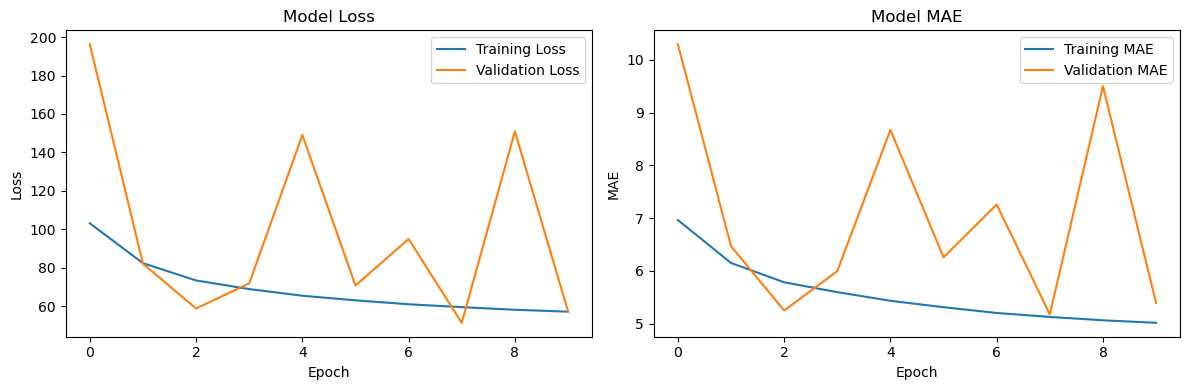

In [23]:
# Plot training history
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['mean_absolute_error'], label='Training MAE')
plt.plot(history.history['val_mean_absolute_error'], label='Validation MAE')
plt.title('Model MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()

plt.tight_layout()
plt.show()